# DELTA1 Strategy — v2.6

A reproducible walkthrough of the single adopted strategy in `strategy.py`: a 61-market global futures portfolio combining 12-month time-series momentum and basis momentum.

**Requested research target:** at least 20% CAGR and 2.0 daily Sharpe over 1990–2004, net of modeled costs.

> **Interpretation warning:** 1990–2004 was explicitly optimized and had been inspected in prior research. This notebook demonstrates a selected-period backtest result, not an untouched holdout, forward expectation, or performance guarantee.

## 1. Environment and data

Set `DELTA1_DATA_DIR` to the supplied Delta1 folder. When it is unset, the notebook uses the repository-local `Round1AllData/Quant Researcher/Delta1` directory.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
%matplotlib inline

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'strategy.py').exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('Run this notebook from the delta1_strategy repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from strategy import (
    GLOBAL_ASSET_CLASSES,
    StrategyConfig,
    load_fx_rates,
    load_unadjusted_prices,
    load_volumes,
    run_backtest,
    run_pipeline,
)

configured_data_dir = os.environ.get('DELTA1_DATA_DIR')
DATA_DIR = (
    Path(configured_data_dir).expanduser()
    if configured_data_dir
    else ROOT / 'Round1AllData' / 'Quant Researcher' / 'Delta1'
).resolve()
OUTPUTS = ROOT / 'outputs'
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f'Data directory not found: {DATA_DIR}. Set DELTA1_DATA_DIR before running.'
    )

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')
print('Repository located successfully.')
print(f"Data source: {'DELTA1_DATA_DIR' if configured_data_dir else 'repository-local dataset'}")

Repository located successfully.
Data source: DELTA1_DATA_DIR


## 2. Frozen strategy specification

For market $i$ at close $t$, the alpha is an equal blend of:

- **12-month sign trend:** $\operatorname{sign}(P_{i,t}-P_{i,t-252})$
- **Basis momentum:** the year-on-year change in trailing realized roll yield, normalized using only trailing observations

The blended forecast is volatility-shock tapered, scaled by the inverse 63-day volatility of its own lagged market-level strategy returns (capped at 2×), and sized with equal nominal pre-forecast volatility budgets across available instruments. Targets form at month-end close and become active on the next business day. Net returns deduct a half-tick spread estimate plus USD 2.50 per contract per one-way trade.

In [2]:
config = StrategyConfig(data_dir=DATA_DIR, output_dir=OUTPUTS)
result, report = run_pipeline(config)

selected_parameters = pd.Series(
    {
        'Markets': len(result.prices.columns),
        'Trend lookback': f'{config.trend_lookback} business days',
        'Basis weight': f'{config.basis_weight:.0%}',
        'Per-market risk window': f'{config.risk_managed_window} business days',
        'Per-market scale cap': f'{config.risk_managed_cap:.1f}x',
        'Risk budget': config.risk_budget,
        'No-trade buffer': f'{config.no_trade_buffer:.0%}',
        'Portfolio volatility target': f'{config.target_vol:.0%}',
        'Portfolio leverage cap': f'{config.max_leverage:.1f}x',
        'Rebalance': 'month-end close; active next business day',
    },
    name='Adopted value',
).to_frame()
display(selected_parameters)

,Adopted value
Markets,61
Trend lookback,252 business days
Basis weight,50%
Per-market risk window,63 business days
Per-market scale cap,2.0x
Risk budget,flat
No-trade buffer,25%
Portfolio volatility target,10%
Portfolio leverage cap,2.0x
Rebalance,month-end close; active next business day


## 3. Net performance and target verdict

The target estimator is fixed as daily net mean divided by daily net standard deviation, zero risk-free rate, annualized by $\sqrt{252}$. CAGR uses elapsed calendar time.

In [3]:
metric_columns = [
    'Window',
    'CAGR',
    'Sharpe (rf=0)',
    'Monthly Sharpe (rf=0)',
    'HAC Sharpe (21 lags, rf=0)',
    'Max drawdown',
    'Annual cost drag',
    'Both targets met',
]
metric_view = report[metric_columns].copy()
for column in ('CAGR', 'Max drawdown', 'Annual cost drag'):
    metric_view[column] = metric_view[column].map(lambda value: f'{value:.2%}')
for column in (
    'Sharpe (rf=0)',
    'Monthly Sharpe (rf=0)',
    'HAC Sharpe (21 lags, rf=0)',
):
    metric_view[column] = metric_view[column].map(lambda value: f'{value:.3f}')
display(metric_view)

indexed_report = report.set_index('Window')
primary = indexed_report.loc['1990-2004 optimized window']
discovery = indexed_report.loc['1990-1997 discovery']
confirmation = indexed_report.loc['1998-2004 confirmation']
later = indexed_report.loc['2005-2014 later stress']
assert bool(primary['Both targets met'])
assert bool(discovery['Both targets met'])
assert bool(confirmation['Both targets met'])
assert not bool(later['Both targets met'])

saved_report = pd.read_csv(OUTPUTS / 'strategy_metrics.csv').set_index('Window')
comparison_columns = [
    'CAGR',
    'Sharpe (rf=0)',
    'Monthly Sharpe (rf=0)',
    'HAC Sharpe (21 lags, rf=0)',
    'Max drawdown',
]
pd.testing.assert_frame_equal(
    indexed_report[comparison_columns].astype(float),
    saved_report[comparison_columns].astype(float),
    rtol=1e-12,
    atol=1e-12,
)
np.testing.assert_allclose(
    primary[comparison_columns].astype(float),
    [
        0.2610900535988423,
        2.1088424570071176,
        1.992846242015627,
        1.9317675887492693,
        -0.11424674073594421,
    ],
    rtol=0,
    atol=5e-10,
)

display(
    Markdown(
        f"**1990–2004:** {primary['CAGR']:.2%} CAGR, "
        f"{primary['Sharpe (rf=0)']:.3f} daily Sharpe, "
        f"{primary['Max drawdown']:.2%} maximum drawdown. "
        f"The monthly and HAC Sharpes are {primary['Monthly Sharpe (rf=0)']:.3f} "
        f"and {primary['HAC Sharpe (21 lags, rf=0)']:.3f}, respectively.**"
    )
)

,Window,CAGR,Sharpe (rf=0),Monthly Sharpe (rf=0),"HAC Sharpe (21 lags, rf=0)",Max drawdown,Annual cost drag,Both targets met
0,1980-1989 backward check,26.01%,2.017,1.826,1.786,-15.76%,0.33%,True
1,1990-1997 discovery,27.22%,2.140,1.902,1.901,-11.42%,0.37%,True
2,1998-2004 confirmation,24.86%,2.072,2.134,1.999,-10.64%,0.28%,True
3,1990-2004 optimized window,26.11%,2.109,1.993,1.932,-11.42%,0.33%,True
4,2005-2014 later stress,16.35%,1.371,1.374,1.329,-14.84%,0.25%,False
5,1980-2014 full history,23.20%,1.871,1.770,1.714,-15.76%,0.31%,False


**1990–2004:** 26.11% CAGR, 2.109 daily Sharpe, -11.42% maximum drawdown. The monthly and HAC Sharpes are 1.993 and 1.932, respectively.**

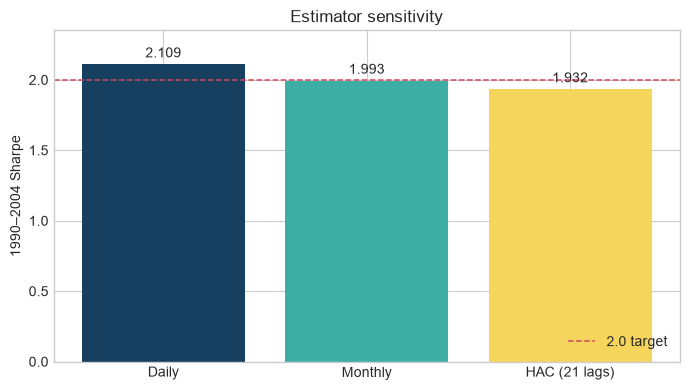

In [4]:
estimator_values = pd.Series(
    {
        'Daily': primary['Sharpe (rf=0)'],
        'Monthly': primary['Monthly Sharpe (rf=0)'],
        'HAC (21 lags)': primary['HAC Sharpe (21 lags, rf=0)'],
    }
)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(estimator_values.index, estimator_values, color=['#173f5f', '#3caea3', '#f6d55c'])
ax.axhline(2.0, color='#d1495b', linestyle='--', linewidth=1.1, label='2.0 target')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 2.35)
ax.set_ylabel('1990–2004 Sharpe')
ax.set_title('Estimator sensitivity')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Equity curve, drawdown, and time variation

The optimized window is shaded. The later 2005–2014 interval is shown separately because it is reused stress evidence and fails the requested threshold.

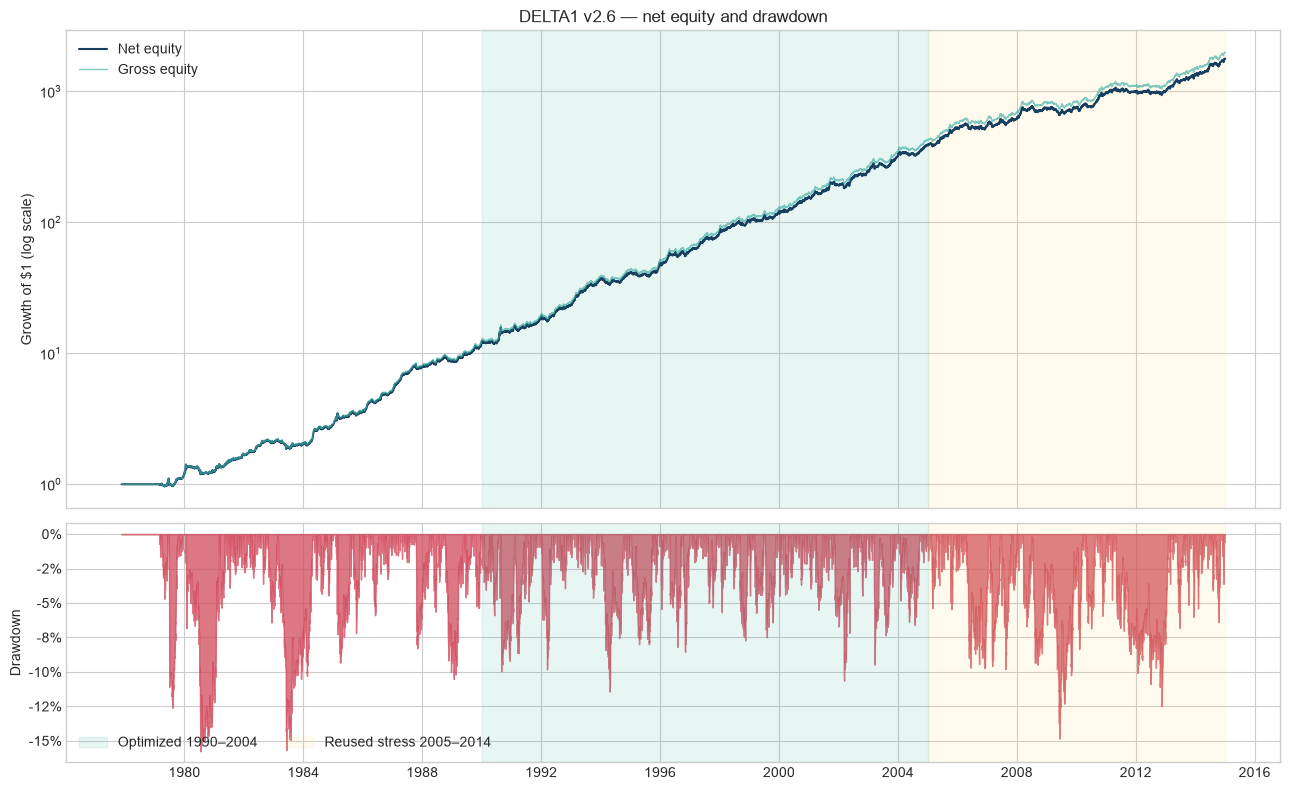

In [5]:
daily = result.daily.copy()
equity = (1 + daily['net_return']).cumprod()
gross_equity = (1 + daily['gross_return']).cumprod()
drawdown = equity / equity.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, height_ratios=[2, 1])
axes[0].plot(equity.index, equity, color='#173f5f', linewidth=1.5, label='Net equity')
axes[0].plot(gross_equity.index, gross_equity, color='#3caea3', linewidth=1.0, alpha=0.65, label='Gross equity')
axes[0].set_yscale('log')
axes[0].set_ylabel('Growth of $1 (log scale)')
axes[0].set_title('DELTA1 v2.6 — net equity and drawdown')
axes[0].legend(loc='upper left')
axes[1].fill_between(drawdown.index, drawdown, 0, color='#d1495b', alpha=0.75)
axes[1].set_ylabel('Drawdown')
axes[1].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')

for axis in axes:
    axis.axvspan(pd.Timestamp('1990-01-01'), pd.Timestamp('2004-12-31'), color='#3caea3', alpha=0.12, label='Optimized 1990–2004')
    axis.axvspan(pd.Timestamp('2005-01-01'), pd.Timestamp('2014-12-31'), color='#f6d55c', alpha=0.10, label='Reused stress 2005–2014')
axes[1].legend(loc='lower left', ncol=2)
plt.tight_layout()
plt.show()

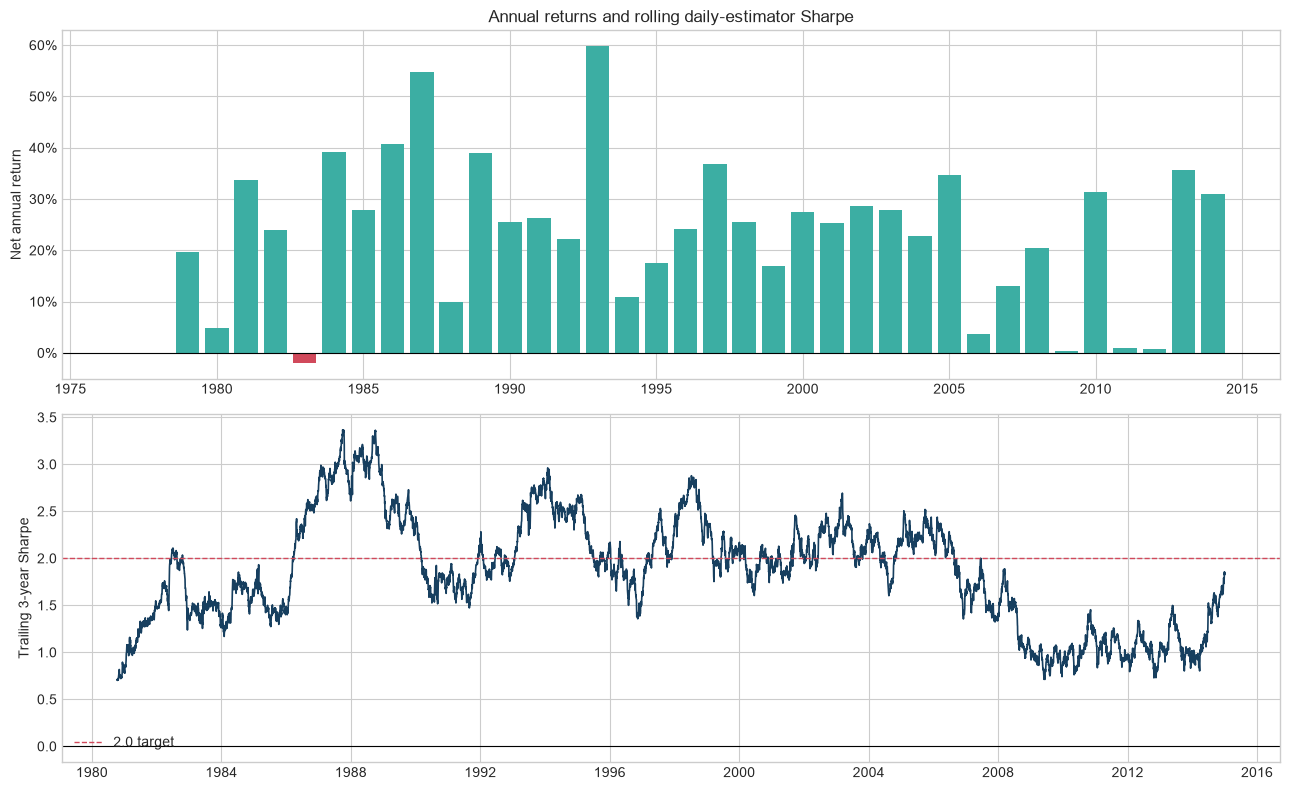

In [6]:
annual_returns = (1 + daily['net_return']).resample('YE').prod() - 1
rolling_window = 3 * config.annualization
rolling_sharpe = (
    daily['net_return'].rolling(rolling_window).mean()
    / daily['net_return'].rolling(rolling_window).std()
    * np.sqrt(config.annualization)
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
bar_colors = np.where(annual_returns >= 0, '#3caea3', '#d1495b')
axes[0].bar(annual_returns.index.year, annual_returns, color=bar_colors, width=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Net annual return')
axes[0].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[0].set_title('Annual returns and rolling daily-estimator Sharpe')

axes[1].plot(rolling_sharpe.index, rolling_sharpe, color='#173f5f', linewidth=1.2)
axes[1].axhline(2.0, color='#d1495b', linestyle='--', linewidth=1.0, label='2.0 target')
axes[1].axhline(0.0, color='black', linewidth=0.8)
axes[1].set_ylabel('Trailing 3-year Sharpe')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

## 5. Optimization audit

The current round contains 50 unique configurations: nine alpha-screen trials and 41 risk/execution trials. The alpha screen retained the existing 12-month trend plus 50/50 basis blend; no new alpha was promoted. `OPT025` is the adopted target-clearing plateau.

In [7]:
ledger = pd.read_csv(OUTPUTS / 'optimization_trials.csv')
varied_columns = [
    'trend_spec',
    'trend_horizons',
    'basis_weight',
    'risk_managed_window',
    'risk_managed_cap',
    'risk_budget',
    'no_trade_buffer',
]
assert len(ledger) == 50
assert len(ledger[varied_columns].drop_duplicates()) == 50
assert ledger['both_subperiods_target_pass'].sum() == 15
assert (ledger['selection_status'] == 'selected_plateau').sum() == 1
with (OUTPUTS / 'strategy_config.json').open(encoding='utf-8') as handle:
    recorded_config = json.load(handle)
assert recorded_config['optimization']['externally_validated'] is False
assert recorded_config['optimization']['prior_archived_target_search_configurations'] == 72
assert recorded_config['optimization']['earlier_archived_variant_minimum'] == 81

selected_trial = ledger.loc[ledger['selection_status'] == 'selected_plateau'].iloc[0]
audit_summary = pd.Series(
    {
        'Unique current-round trials': len(ledger),
        'Alpha-screen trials': int((ledger['stage'] == 'alpha_screen').sum()),
        'Risk/execution trials': int((ledger['stage'] == 'risk_execution').sum()),
        'Combined-window target passes': int(ledger['combined_target_pass'].sum()),
        'Both-subperiod target passes': int(ledger['both_subperiods_target_pass'].sum()),
        'Selected trial': selected_trial['trial_id'],
        'Selected combined Sharpe': f"{selected_trial['combined_sharpe']:.3f}",
        'Selected minimum-subperiod rank': int(selected_trial['numeric_rank_among_cagr_eligible']),
    },
    name='Value',
).to_frame()
display(audit_summary)

top_trials = ledger.nlargest(10, 'combined_sharpe')[
    [
        'trial_id',
        'basis_weight',
        'risk_managed_window',
        'risk_managed_cap',
        'risk_budget',
        'no_trade_buffer',
        'discovery_sharpe',
        'confirmation_sharpe',
        'combined_cagr',
        'combined_sharpe',
        'selection_status',
    ]
].copy()
top_trials['combined_cagr'] = top_trials['combined_cagr'].map(lambda value: f'{value:.2%}')
for column in ('discovery_sharpe', 'confirmation_sharpe', 'combined_sharpe'):
    top_trials[column] = top_trials[column].map(lambda value: f'{value:.3f}')
display(top_trials)

,Value
Unique current-round trials,50
Alpha-screen trials,9
Risk/execution trials,41
Combined-window target passes,20
Both-subperiod target passes,15
Selected trial,OPT025
Selected combined Sharpe,2.109
Selected minimum-subperiod rank,5


,trial_id,basis_weight,risk_managed_window,risk_managed_cap,risk_budget,no_trade_buffer,discovery_sharpe,confirmation_sharpe,combined_cagr,combined_sharpe,selection_status
24,OPT025,0.5,63.0,2.0,flat,0.25,2.140,2.072,26.11%,2.109,selected_plateau
23,OPT024,0.5,63.0,2.0,flat,0.00,2.146,2.055,26.34%,2.105,not_selected
18,OPT019,0.5,63.0,1.5,flat,0.25,2.134,2.065,26.37%,2.102,not_selected
29,OPT030,0.5,126.0,1.5,flat,0.00,2.124,2.074,26.63%,2.101,not_selected
35,OPT036,0.5,126.0,2.0,flat,0.00,2.119,2.080,26.46%,2.100,numeric_max_not_selected
47,OPT048,0.5,252.0,2.0,flat,0.00,2.119,2.078,26.23%,2.100,not_selected
41,OPT042,0.5,252.0,1.5,flat,0.00,2.118,2.065,26.23%,2.094,not_selected
17,OPT018,0.5,63.0,1.5,flat,0.00,2.142,2.030,26.33%,2.091,not_selected
30,OPT031,0.5,126.0,1.5,flat,0.25,2.063,2.118,26.22%,2.087,not_selected
48,OPT049,0.5,252.0,2.0,flat,0.25,2.096,2.075,25.91%,2.086,not_selected


## 6. Robustness and dependency analysis

Local parameter stability is distinct from structural robustness. The nearby risk windows, caps, buffers, and doubled costs all retain the target in both internal subperiods. Removing a construction component or an entire asset class does not.

,Rows,Pass all 1990–2004 windows
Parameter neighbors,8,8
Doubled costs,1,1
Construction ablations,3,0
Leave one class out,6,0


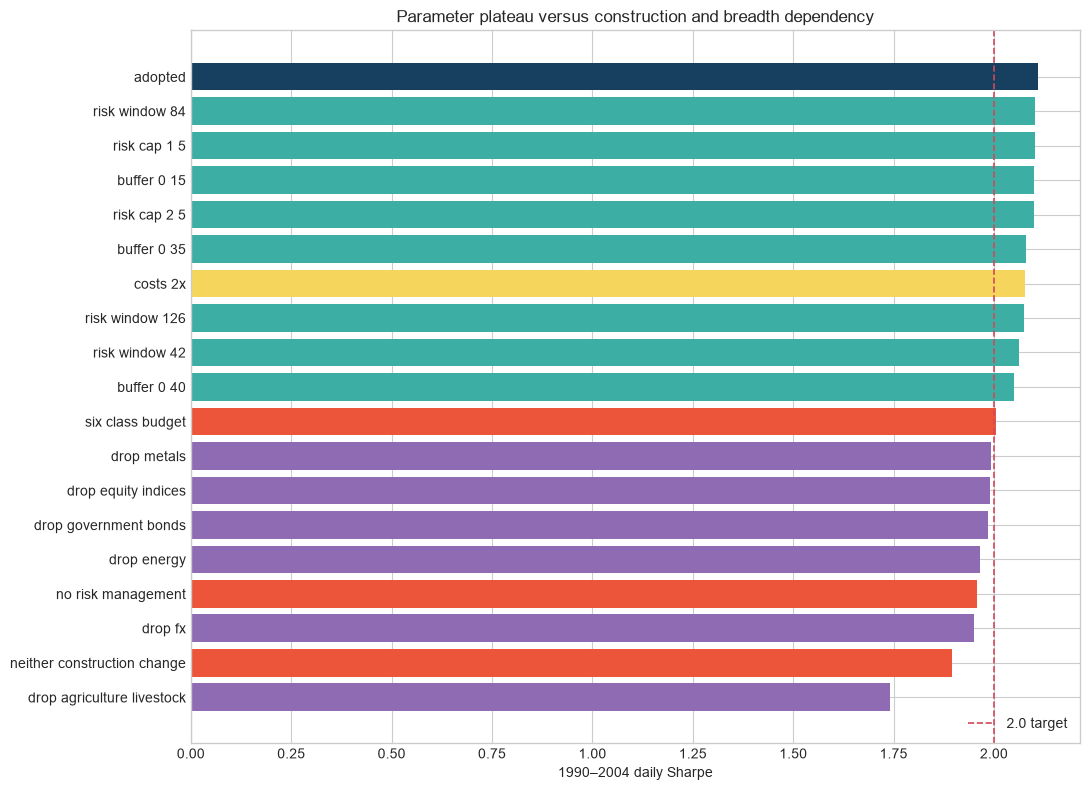

In [8]:
robustness = pd.read_csv(OUTPUTS / 'strategy_robustness.csv')
assert len(robustness) == 19
assert robustness['variant'].nunique() == 19
local_stresses = robustness['category'].isin(['parameter_neighbor', 'cost_stress'])
assert bool(robustness.loc[local_stresses, 'all_windows_pass'].all())
assert not bool(robustness.loc[robustness['category'] == 'construction_ablation', 'all_windows_pass'].any())
assert not bool(robustness.loc[robustness['category'] == 'leave_one_class_out', 'all_windows_pass'].any())
assert not bool(robustness['later_stress_pass'].any())

robustness_summary = pd.DataFrame(
    {
        'Rows': [
            int((robustness['category'] == 'parameter_neighbor').sum()),
            int((robustness['category'] == 'cost_stress').sum()),
            int((robustness['category'] == 'construction_ablation').sum()),
            int((robustness['category'] == 'leave_one_class_out').sum()),
        ],
        'Pass all 1990–2004 windows': [
            int(robustness.loc[robustness['category'] == 'parameter_neighbor', 'all_windows_pass'].sum()),
            int(robustness.loc[robustness['category'] == 'cost_stress', 'all_windows_pass'].sum()),
            int(robustness.loc[robustness['category'] == 'construction_ablation', 'all_windows_pass'].sum()),
            int(robustness.loc[robustness['category'] == 'leave_one_class_out', 'all_windows_pass'].sum()),
        ],
    },
    index=['Parameter neighbors', 'Doubled costs', 'Construction ablations', 'Leave one class out'],
)
display(robustness_summary)

plot_data = robustness.sort_values('combined_sharpe')
category_colors = {
    'adopted': '#173f5f',
    'parameter_neighbor': '#3caea3',
    'cost_stress': '#f6d55c',
    'construction_ablation': '#ed553b',
    'leave_one_class_out': '#8f6bb3',
}
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    plot_data['variant'].str.replace('_', ' '),
    plot_data['combined_sharpe'],
    color=plot_data['category'].map(category_colors),
)
ax.axvline(2.0, color='#d1495b', linestyle='--', linewidth=1.2, label='2.0 target')
ax.set_xlabel('1990–2004 daily Sharpe')
ax.set_title('Parameter plateau versus construction and breadth dependency')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Timing and no-lookahead audit

The strongest reproducibility check reruns the entire pipeline with every time-series input physically truncated at 2004-12-31. Pre-cutoff forecasts, executable positions, and returns must be exactly identical to the full-data run.

In [9]:
cutoff = '2004-12-31'
truncated_prices = result.prices.loc[:cutoff]
truncated_result = run_backtest(
    config,
    prices=truncated_prices,
    unadjusted=load_unadjusted_prices(DATA_DIR).loc[:cutoff],
    metadata=result.metadata,
    volumes=load_volumes(DATA_DIR).loc[:cutoff],
    fx_rates=load_fx_rates(DATA_DIR, truncated_prices.index),
)

pd.testing.assert_series_equal(
    result.daily.loc[:cutoff, 'net_return'],
    truncated_result.daily['net_return'],
)
pd.testing.assert_frame_equal(result.positions.loc[:cutoff], truncated_result.positions)
pd.testing.assert_frame_equal(result.signals.loc[:cutoff], truncated_result.signals)
expected_positions = (
    result.target_positions.reindex(result.prices.index).ffill().shift(1).fillna(0.0)
)
pd.testing.assert_frame_equal(result.positions, expected_positions)

position_changed = result.positions.diff().abs().sum(axis=1).gt(1e-15)
month = pd.Series(result.positions.index.to_period('M'), index=result.positions.index)
first_business_day = month.ne(month.shift(1))
changes_only_at_month_boundary = bool(
    (~position_changed.iloc[1:] | first_business_day.iloc[1:]).all()
)
checks = pd.Series(
    {
        'Full-pipeline truncation invariance': True,
        'Positions change only on first business day': changes_only_at_month_boundary,
        'Signals bounded by 1': bool(result.signals.abs().max().max() <= 1.0),
        'Modeled costs non-negative': bool((result.daily['cost'] >= 0).all()),
        'Net returns finite': bool(np.isfinite(result.daily['net_return']).all()),
    },
    name='Pass',
).to_frame()
assert bool(checks['Pass'].all())
display(checks)

,Pass
Full-pipeline truncation invariance,True
Positions change only on first business day,True
Signals bounded by 1,True
Modeled costs non-negative,True
Net returns finite,True


## 8. Conclusion

The requested **1990–2004 backtest** threshold is achieved net of modeled costs: approximately **26.11% CAGR and 2.109 daily Sharpe**, with both internal halves above 2.0. No additional alpha signal survived the screen; the uplift comes from portfolio construction.

The honest boundary is equally important: monthly and autocorrelation-adjusted Sharpes are below 2.0, 2005–2014 records only 1.37, all periods have been inspected previously, and the result depends on retaining broad cross-asset coverage. The current 50 trials sit alongside a separate archived 72-configuration target search and at least 81 earlier variants, with unknown cross-round overlap and no multiplicity adjustment. Treat this as reproducible historical research—not an expected return, investment recommendation, or guarantee.